**Sample Entropy (order = 2, tolerance = 0.2)**

In [17]:
# BEN CODE — z-score normalized, correct ROI count for order = 2

!pip install antropy pandas numpy tqdm joblib --quiet

import os
import zipfile
import numpy as np
import pandas as pd
from tqdm import tqdm
from antropy import sample_entropy
from joblib import Parallel, delayed
import multiprocessing

csv_path  = "/content/MINI_label.csv"
zip_path  = "/content/netts_files.zip"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

extract_folder = "/content/netts_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

data_folder = "/content/netts_data/Glasser_HCP"
print("Total files:", len(os.listdir(data_folder)))

# BEN FUNCTION — with z-score normalization (critical fix)
def compute_subject_ben(row):
    try:
        usercode = str(int(row["User.code"]))
        filename = f"sub-{usercode.zfill(12)}_000.netts"
        filepath = os.path.join(data_folder, filename)

        if not os.path.exists(filepath):
            return None

        ts = np.loadtxt(filepath)         # shape: (360, n_rois) — n_rois=164 or 155

        if ts.ndim == 1:
            ts = ts.reshape(-1, 1)

        roi_entropy = []

        for col in range(ts.shape[1]):
            signal = ts[:, col]
            signal = signal[~np.isnan(signal)]

            if len(signal) < 10:
                continue

            std = np.std(signal)
            if std < 1e-10:
                continue

            # CRITICAL FIX: z-score normalize before SampleEntropy
            # Without this, r = 0.2 * ~2700 = huge → all subjects get ~same SE
            signal = (signal - np.mean(signal)) / std

            try:
                # order=2, r=0.2*std=0.2 (since std=1 after z-score) — standard params
                e = sample_entropy(signal, order=2, tolerance=0.2)
                if np.isfinite(e):
                    roi_entropy.append(float(e))
            except:
                continue

        if len(roi_entropy) == 0:
            return None

        return [usercode, float(np.mean(roi_entropy))]

    except:
        return None

# PARALLEL PROCESSING
n_jobs = multiprocessing.cpu_count()
print(f"Using {n_jobs} CPU cores")

results = Parallel(n_jobs=n_jobs)(
    delayed(compute_subject_ben)(row)
    for _, row in tqdm(df.iterrows(), total=len(df))
)

results = [r for r in results if r is not None]

res = pd.DataFrame(results, columns=["User.code", "BEN"])

# Quick sanity check — BEN should vary meaningfully across subjects
print(f"\nTotal subjects processed: {len(res)}")
print(f"BEN range   : {res['BEN'].min():.4f} → {res['BEN'].max():.4f}")
print(f"BEN mean    : {res['BEN'].mean():.4f}")
print(f"BEN std     : {res['BEN'].std():.4f}")        # should be > 0.05 if working correctly
print(res.head(10))

res.to_csv("/content/BEN_values_order2.csv", index=False)
print("Saved BEN_values_order2.csv")

Total files: 1024
Using 2 CPU cores


100%|██████████| 8351/8351 [00:54<00:00, 153.69it/s]



Total subjects processed: 988
BEN range   : 1.1405 → 1.9054
BEN mean    : 1.5008
BEN std     : 0.1092
  User.code       BEN
0  10155078  1.642470
1  10218000  1.527128
2  10225245  1.455978
3  10229783  1.500486
4  10382566  1.443651
5  10387970  1.575219
6  10450441  1.648580
7  10488996  1.660435
8  10574254  1.728657
9  10683468  1.309651
Saved BEN_values_order2.csv


Condition
Healthy      795
Unhealthy    193
Name: count, dtype: int64


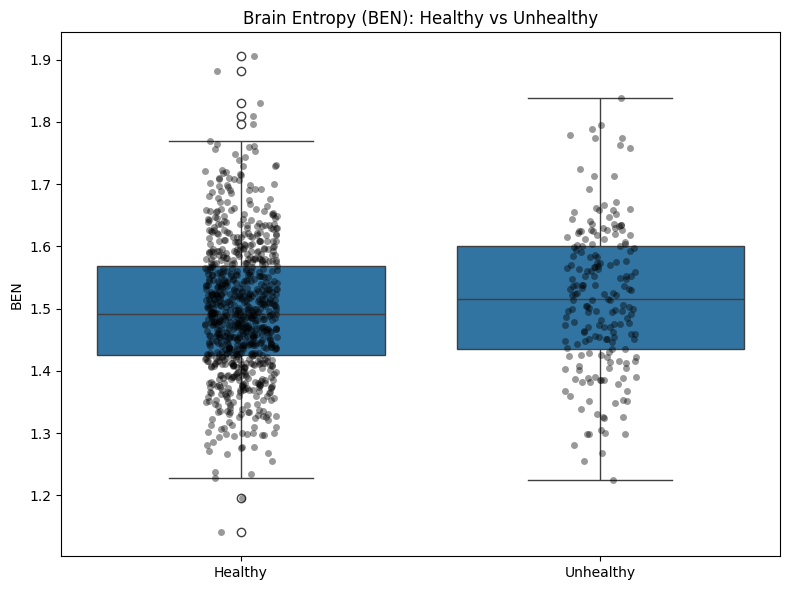

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load files
labels = pd.read_csv("/content/MINI_label.csv")
ben = pd.read_csv("/content/BEN_values_order2.csv")

labels.columns = labels.columns.str.strip()

# Merge
df = pd.merge(labels, ben, on="User.code")

# Healthy vs Unhealthy
df["Condition"] = df.apply(
    lambda row: "Healthy"
    if row["externalizing_spectrum"]==0 and
       row["internalizing_spectrum"]==0 and
       row["mood_psychosis_spectrum"]==0
    else "Unhealthy",
    axis=1
)

print(df["Condition"].value_counts())

# Plot
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x="Condition", y="BEN")

sns.stripplot(data=df, x="Condition", y="BEN",
              color="black", alpha=0.4)

plt.title("Brain Entropy (BEN): Healthy vs Unhealthy")
plt.ylabel("BEN")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# LOAD FILES
labels = pd.read_csv("/content/MINI_label.csv")
ben = pd.read_csv("/content/BEN_values_order2.csv")

labels.columns = labels.columns.str.strip()


# MERGE ON User.code
df = pd.merge(labels, ben, on="User.code")
df["Condition"] = df.apply(
    lambda row: "Healthy"
    if row["externalizing_spectrum"] == 0 and
       row["internalizing_spectrum"] == 0 and
       row["mood_psychosis_spectrum"] == 0
    else "Unhealthy",
    axis=1
)

# CALCULATE MEANS
group_stats = df.groupby("Condition")["BEN"].agg(
    Count="count",
    Mean="mean",
    Std="std",
    Median="median",
    Min="min",
    Max="max"
)

print(group_stats)

# OUTPUT
healthy_mean = df[df["Condition"]=="Healthy"]["BEN"].mean()
unhealthy_mean = df[df["Condition"]=="Unhealthy"]["BEN"].mean()

print("\nMean BEN Values:")
print("Healthy   :", round(healthy_mean,4))
print("Unhealthy :", round(unhealthy_mean,4))
print("Difference:", round(unhealthy_mean - healthy_mean,4))

           Count      Mean       Std    Median       Min       Max
Condition                                                         
Healthy      795  1.497177  0.106876  1.490847  1.140547  1.905415
Unhealthy    193  1.515662  0.117200  1.515026  1.225245  1.838895

Mean BEN Values:
Healthy   : 1.4972
Unhealthy : 1.5157
Difference: 0.0185


In [20]:
from scipy.stats import mannwhitneyu

h = df[df["Condition"]=="Healthy"]["BEN"]
u = df[df["Condition"]=="Unhealthy"]["BEN"]

stat,p = mannwhitneyu(h,u,alternative="two-sided")

print("p =",p)

p = 0.029345595409198018


Group counts:
Condition
Healthy           795
Externalizing      89
Mood-Psychosis     64
Internalizing      40
Name: count, dtype: int64



/tmp/ipykernel_2282/3474869364.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved → /content/BEN_boxplot_order2.png


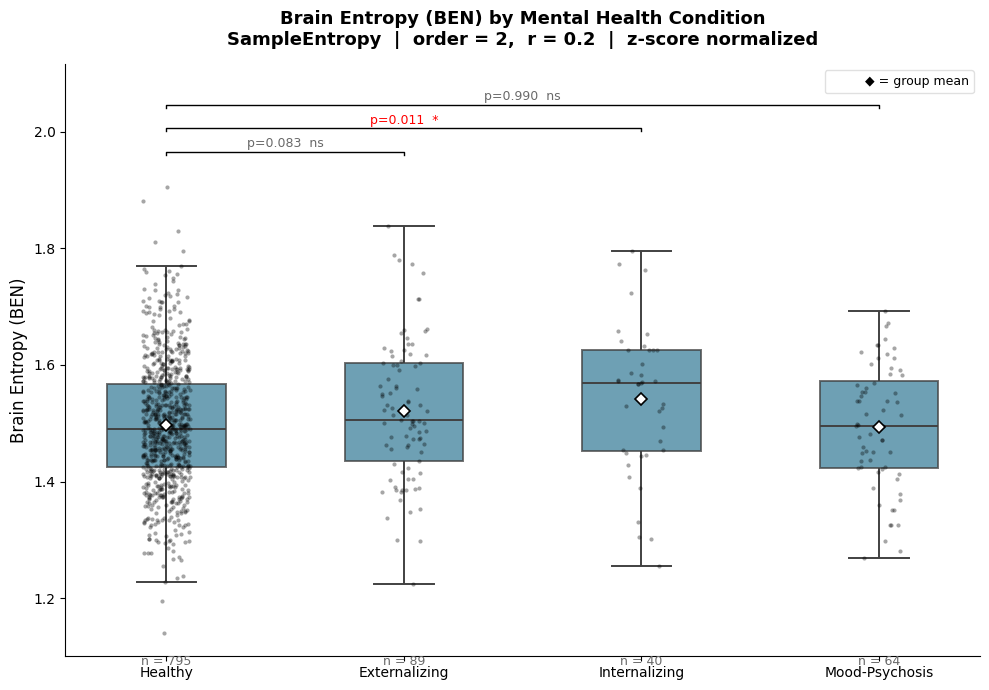


 Group Statistics: 
                  N    Mean     Std  Median     Min     Max
Condition                                                  
Externalizing    89  1.5204  0.1190  1.5056  1.2252  1.8389
Healthy         795  1.4972  0.1069  1.4908  1.1405  1.9054
Internalizing    40  1.5411  0.1271  1.5682  1.2548  1.7946
Mood-Psychosis   64  1.4932  0.1055  1.4961  1.2683  1.6919


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu

# LOAD
labels = pd.read_csv("/content/MINI_label.csv")
ben    = pd.read_csv("/content/BEN_values_order2.csv")

labels.columns = labels.columns.str.strip()
df = pd.merge(labels, ben, on="User.code")

# ASSIGN CONDITION

def assign_condition(row):
    ext = row["externalizing_spectrum"]
    int_ = row["internalizing_spectrum"]
    moo = row["mood_psychosis_spectrum"]

    if ext == 0 and int_ == 0 and moo == 0:
        return "Healthy"
    elif moo == 1:
        return "Mood-Psychosis"
    elif ext == 1:
        return "Externalizing"
    else:
        return "Internalizing"

df["Condition"] = df.apply(assign_condition, axis=1)

print("Group counts:")
print(df["Condition"].value_counts())
print()

# PLOT SETUP
order   = ["Healthy", "Externalizing", "Internalizing", "Mood-Psychosis"]
palette = {
    "Healthy":          "#2E86AB",
    "Externalizing":    "#2E86AB",
    "Internalizing":    "#2E86AB",
    "Mood-Psychosis":   "#2E86AB",
}

fig, ax = plt.subplots(figsize=(10, 7))

# BOXPLOT
sns.boxplot(
    data     = df,
    x        = "Condition",
    y        = "BEN",
    order    = order,
    palette  = palette,
    width    = 0.5,
    linewidth= 1.4,
    fliersize= 0,          # hide default outlier dots — shown by stripplot
    ax       = ax,
    boxprops = dict(alpha=0.75),
)

# STRIPPLOT (individual dots)
sns.stripplot(
    data    = df,
    x       = "Condition",
    y       = "BEN",
    order   = order,
    color   = "black",
    size    = 3,
    alpha   = 0.35,
    jitter  = True,
    ax      = ax,
)

# MEAN MARKERS
for i, cond in enumerate(order):
    mean_val = df[df["Condition"] == cond]["BEN"].mean()
    ax.plot(i, mean_val, marker="D", color="white",
            markersize=6, markeredgecolor="black",
            markeredgewidth=1.2, zorder=5, label="_nolegend_")

# SIGNIFICANCE STARS (vs Healthy)
healthy_ben = df[df["Condition"] == "Healthy"]["BEN"]
y_top       = df["BEN"].max() + 0.03
gap         = 0.03

for i, cond in enumerate(order[1:], start=1):
    group_ben = df[df["Condition"] == cond]["BEN"]
    if len(group_ben) < 2:
        continue
    stat, p = mannwhitneyu(healthy_ben, group_ben, alternative="two-sided")

    # significance label
    if   p < 0.001: sig = "***"
    elif p < 0.01:  sig = "**"
    elif p < 0.05:  sig = "*"
    else:           sig = "ns"

    bar_y = y_top + gap
    # draw bracket line
    ax.plot([0, 0, i, i],
            [bar_y - 0.005, bar_y, bar_y, bar_y - 0.005],
            color="black", linewidth=1.0)
    # p-value text
    ax.text((0 + i) / 2, bar_y + 0.003,
            f"p={p:.3f}  {sig}",
            ha="center", va="bottom", fontsize=9,
            color="red" if p < 0.05 else "dimgray")
    gap += 0.04

# LABELS & STYLING
ax.set_title(
    "Brain Entropy (BEN) by Mental Health Condition\n"
    "SampleEntropy  |  order = 2,  r = 0.2  |  z-score normalized",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_ylabel("Brain Entropy (BEN)", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(df["BEN"].min() - 0.04, y_top + gap + 0.03)

# add sample-size annotation under each x-tick
for i, cond in enumerate(order):
    n = len(df[df["Condition"] == cond])
    ax.text(i, df["BEN"].min() - 0.055, f"n = {n}",
            ha="center", fontsize=9, color="dimgray")

# mean diamond legend
diamond_patch = mpatches.Patch(color="white", label="◆ = group mean",
                                linewidth=1.2)
ax.legend(handles=[diamond_patch], loc="upper right",
          fontsize=9, framealpha=0.6)

sns.despine()
plt.tight_layout()
plt.savefig("/content/BEN_boxplot_order2.png", dpi=150, bbox_inches="tight")
print("Saved → /content/BEN_boxplot_order2.png")
plt.show()

# PRINT STATS TABLE
print("\n Group Statistics: ")
stats = df.groupby("Condition")["BEN"].agg(
    N      = "count",
    Mean   = "mean",
    Std    = "std",
    Median = "median",
    Min    = "min",
    Max    = "max",
)
print(stats.round(4).to_string())

**Sample Entropy (order = 3, tolerance = 0.6) -> as per the paper**

In [22]:
# BEN CODE — z-score normalized, correct ROI count for order = 3

!pip install antropy pandas numpy tqdm joblib --quiet

import os
import zipfile
import numpy as np
import pandas as pd
from tqdm import tqdm
from antropy import sample_entropy
from joblib import Parallel, delayed
import multiprocessing

csv_path  = "/content/MINI_label.csv"
zip_path  = "/content/netts_files.zip"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

extract_folder = "/content/netts_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

data_folder = "/content/netts_data/Glasser_HCP"
print("Total files:", len(os.listdir(data_folder)))

# BEN FUNCTION — with z-score normalization (critical fix)
def compute_subject_ben(row):
    try:
        usercode = str(int(row["User.code"]))
        filename = f"sub-{usercode.zfill(12)}_000.netts"
        filepath = os.path.join(data_folder, filename)

        if not os.path.exists(filepath):
            return None

        ts = np.loadtxt(filepath)         # shape: (360, n_rois) — n_rois=164 or 155

        if ts.ndim == 1:
            ts = ts.reshape(-1, 1)

        roi_entropy = []

        for col in range(ts.shape[1]):
            signal = ts[:, col]
            signal = signal[~np.isnan(signal)]

            if len(signal) < 10:
                continue

            std = np.std(signal)
            if std < 1e-10:
                continue

            # CRITICAL FIX: z-score normalize before SampleEntropy
            # Without this, r = 0.2 * ~2700 = huge → all subjects get ~same SE
            signal = (signal - np.mean(signal)) / std

            try:
                # order=3 r=0.6 as per the paper
                e = sample_entropy(signal, order=3, tolerance=0.6)
                if np.isfinite(e):
                    roi_entropy.append(float(e))
            except:
                continue

        if len(roi_entropy) == 0:
            return None

        return [usercode, float(np.mean(roi_entropy))]

    except:
        return None

# PARALLEL PROCESSING
n_jobs = multiprocessing.cpu_count()
print(f"Using {n_jobs} CPU cores")

results = Parallel(n_jobs=n_jobs)(
    delayed(compute_subject_ben)(row)
    for _, row in tqdm(df.iterrows(), total=len(df))
)

results = [r for r in results if r is not None]

res = pd.DataFrame(results, columns=["User.code", "BEN"])

# Quick sanity check — BEN should vary meaningfully across subjects
print(f"\nTotal subjects processed: {len(res)}")
print(f"BEN range   : {res['BEN'].min():.4f} → {res['BEN'].max():.4f}")
print(f"BEN mean    : {res['BEN'].mean():.4f}")
print(f"BEN std     : {res['BEN'].std():.4f}")        # should be > 0.05 if working correctly
print(res.head(10))

res.to_csv("/content/BEN_values_order3.csv", index=False)
print("Saved BEN_values_order3.csv")

Total files: 1024
Using 2 CPU cores


100%|██████████| 8351/8351 [00:47<00:00, 175.70it/s]



Total subjects processed: 988
BEN range   : 0.4209 → 0.8307
BEN mean    : 0.6183
BEN std     : 0.0648
  User.code       BEN
0  10155078  0.712079
1  10218000  0.597646
2  10225245  0.621869
3  10229783  0.611496
4  10382566  0.602230
5  10387970  0.653694
6  10450441  0.676718
7  10488996  0.706392
8  10574254  0.696565
9  10683468  0.598125
Saved BEN_values_order3.csv


Condition
Healthy      795
Unhealthy    193
Name: count, dtype: int64


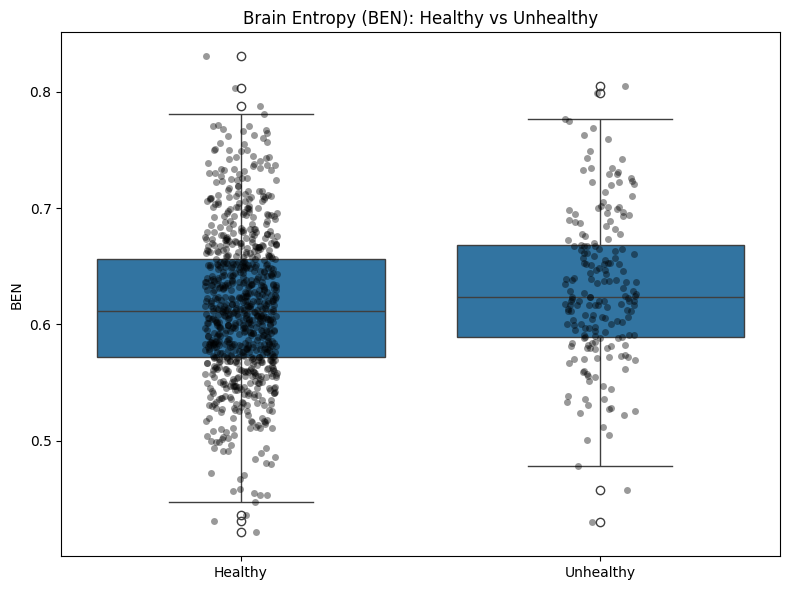

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load files
labels = pd.read_csv("/content/MINI_label.csv")
ben = pd.read_csv("/content/BEN_values_order3.csv")

labels.columns = labels.columns.str.strip()

# Merge
df = pd.merge(labels, ben, on="User.code")

# Healthy vs Unhealthy
df["Condition"] = df.apply(
    lambda row: "Healthy"
    if row["externalizing_spectrum"]==0 and
       row["internalizing_spectrum"]==0 and
       row["mood_psychosis_spectrum"]==0
    else "Unhealthy",
    axis=1
)

print(df["Condition"].value_counts())

# Plot
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x="Condition", y="BEN")

sns.stripplot(data=df, x="Condition", y="BEN",
              color="black", alpha=0.4)

plt.title("Brain Entropy (BEN): Healthy vs Unhealthy")
plt.ylabel("BEN")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd

# LOAD FILES
labels = pd.read_csv("/content/MINI_label.csv")
ben = pd.read_csv("/content/BEN_values_order3.csv")

labels.columns = labels.columns.str.strip()


# MERGE ON User.code
df = pd.merge(labels, ben, on="User.code")
df["Condition"] = df.apply(
    lambda row: "Healthy"
    if row["externalizing_spectrum"] == 0 and
       row["internalizing_spectrum"] == 0 and
       row["mood_psychosis_spectrum"] == 0
    else "Unhealthy",
    axis=1
)

# CALCULATE MEANS
group_stats = df.groupby("Condition")["BEN"].agg(
    Count="count",
    Mean="mean",
    Std="std",
    Median="median",
    Min="min",
    Max="max"
)

print(group_stats)

# OUTPUT
healthy_mean = df[df["Condition"]=="Healthy"]["BEN"].mean()
unhealthy_mean = df[df["Condition"]=="Unhealthy"]["BEN"].mean()

print("\nMean BEN Values:")
print("Healthy   :", round(healthy_mean,4))
print("Unhealthy :", round(unhealthy_mean,4))
print("Difference:", round(unhealthy_mean - healthy_mean,4))

           Count      Mean       Std    Median       Min       Max
Condition                                                         
Healthy      795  0.615253  0.064364  0.611614  0.420906  0.830748
Unhealthy    193  0.630620  0.065241  0.623427  0.430288  0.804964

Mean BEN Values:
Healthy   : 0.6153
Unhealthy : 0.6306
Difference: 0.0154


In [25]:
from scipy.stats import mannwhitneyu

h = df[df["Condition"]=="Healthy"]["BEN"]
u = df[df["Condition"]=="Unhealthy"]["BEN"]

stat,p = mannwhitneyu(h,u,alternative="two-sided")

print("p =",p)

p = 0.0027734721957543814


Group counts:
Condition
Healthy           795
Externalizing      89
Mood-Psychosis     64
Internalizing      40
Name: count, dtype: int64



/tmp/ipykernel_2282/3081306087.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved → /content/BEN_boxplot_order3.png


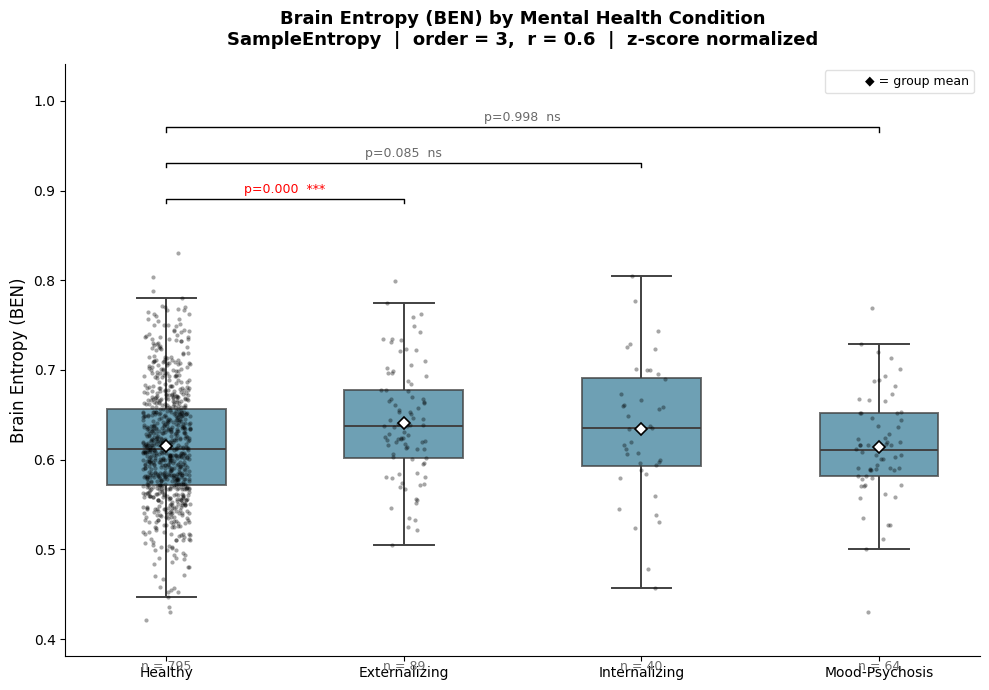


 Group Statistics: 
                  N    Mean     Std  Median     Min     Max
Condition                                                  
Externalizing    89  0.6411  0.0627  0.6376  0.5046  0.7989
Healthy         795  0.6153  0.0644  0.6116  0.4209  0.8307
Internalizing    40  0.6340  0.0767  0.6349  0.4574  0.8050
Mood-Psychosis   64  0.6139  0.0583  0.6103  0.4303  0.7689


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu

# LOAD
labels = pd.read_csv("/content/MINI_label.csv")
ben    = pd.read_csv("/content/BEN_values_order3.csv")

labels.columns = labels.columns.str.strip()
df = pd.merge(labels, ben, on="User.code")

# ASSIGN CONDITION

def assign_condition(row):
    ext = row["externalizing_spectrum"]
    int_ = row["internalizing_spectrum"]
    moo = row["mood_psychosis_spectrum"]

    if ext == 0 and int_ == 0 and moo == 0:
        return "Healthy"
    elif moo == 1:
        return "Mood-Psychosis"
    elif ext == 1:
        return "Externalizing"
    else:
        return "Internalizing"

df["Condition"] = df.apply(assign_condition, axis=1)

print("Group counts:")
print(df["Condition"].value_counts())
print()

# PLOT SETUP
order   = ["Healthy", "Externalizing", "Internalizing", "Mood-Psychosis"]
palette = {
    "Healthy":          "#2E86AB",
    "Externalizing":    "#2E86AB",
    "Internalizing":    "#2E86AB",
    "Mood-Psychosis":"#2E86AB",
}

fig, ax = plt.subplots(figsize=(10, 7))

# BOXPLOT
sns.boxplot(
    data     = df,
    x        = "Condition",
    y        = "BEN",
    order    = order,
    palette  = palette,
    width    = 0.5,
    linewidth= 1.4,
    fliersize= 0,          # hide default outlier dots — shown by stripplot
    ax       = ax,
    boxprops = dict(alpha=0.75),
)

# STRIPPLOT (individual dots)
sns.stripplot(
    data    = df,
    x       = "Condition",
    y       = "BEN",
    order   = order,
    color   = "black",
    size    = 3,
    alpha   = 0.35,
    jitter  = True,
    ax      = ax,
)

# MEAN MARKERS
for i, cond in enumerate(order):
    mean_val = df[df["Condition"] == cond]["BEN"].mean()
    ax.plot(i, mean_val, marker="D", color="white",
            markersize=6, markeredgecolor="black",
            markeredgewidth=1.2, zorder=5, label="_nolegend_")

# SIGNIFICANCE STARS (vs Healthy)
healthy_ben = df[df["Condition"] == "Healthy"]["BEN"]
y_top       = df["BEN"].max() + 0.03
gap         = 0.03

for i, cond in enumerate(order[1:], start=1):
    group_ben = df[df["Condition"] == cond]["BEN"]
    if len(group_ben) < 2:
        continue
    stat, p = mannwhitneyu(healthy_ben, group_ben, alternative="two-sided")

    # significance label
    if   p < 0.001: sig = "***"
    elif p < 0.01:  sig = "**"
    elif p < 0.05:  sig = "*"
    else:           sig = "ns"

    bar_y = y_top + gap
    # draw bracket line
    ax.plot([0, 0, i, i],
            [bar_y - 0.005, bar_y, bar_y, bar_y - 0.005],
            color="black", linewidth=1.0)
    # p-value text
    ax.text((0 + i) / 2, bar_y + 0.003,
            f"p={p:.3f}  {sig}",
            ha="center", va="bottom", fontsize=9,
            color="red" if p < 0.05 else "dimgray")
    gap += 0.04

# LABELS & STYLING
ax.set_title(
    "Brain Entropy (BEN) by Mental Health Condition\n"
    "SampleEntropy  |  order = 3,  r = 0.6  |  z-score normalized",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_ylabel("Brain Entropy (BEN)", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(df["BEN"].min() - 0.04, y_top + gap + 0.03)

# add sample-size annotation under each x-tick
for i, cond in enumerate(order):
    n = len(df[df["Condition"] == cond])
    ax.text(i, df["BEN"].min() - 0.055, f"n = {n}",
            ha="center", fontsize=9, color="dimgray")

# mean diamond legend
diamond_patch = mpatches.Patch(color="white", label="◆ = group mean",
                                linewidth=1.2)
ax.legend(handles=[diamond_patch], loc="upper right",
          fontsize=9, framealpha=0.6)

sns.despine()
plt.tight_layout()
plt.savefig("/content/BEN_boxplot_order3.png", dpi=150, bbox_inches="tight")
print("Saved → /content/BEN_boxplot_order3.png")
plt.show()

# PRINT STATS TABLE
print("\n Group Statistics: ")
stats = df.groupby("Condition")["BEN"].agg(
    N      = "count",
    Mean   = "mean",
    Std    = "std",
    Median = "median",
    Min    = "min",
    Max    = "max",
)
print(stats.round(4).to_string())